# E-Commerce Review Sentiment Analysis (DistilBERT)

Production-style NLP pipeline for classifying product reviews into **negative** and **positive** sentiment.

## Why this project matters
- Demonstrates transfer learning with Hugging Face Transformers.
- Handles class imbalance using weighted loss.
- Includes reproducible training, structured evaluation, and model export for inference.

## Project workflow

1. Tokenizer
2. Token IDs + Attention Mask
3. Dataset Class
4. DistilBERT Model
5. Trainer API (training)
6. Predictions
7. Evaluation Metrics

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from datasets import Dataset
from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizer,
    Trainer,
    TrainingArguments,
)
import re
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics import classification_report

from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm import tqdm

SEED = 42


d:\vscode\E-Commerce-Review-Intelligence-System\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Prefer a local data/ folder for portability.
DATA_PATH = Path("data/7817_1.csv")

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")

df.sample(5, random_state=SEED)

Dataset shape: (1597, 27)


,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
802,AVpe7LD5LJeJML43ybWA,"B00DOPNO4M,B00BWYQ9YE,B00CYQPMJC,B00CUU1CGY,B0...",Amazon,"Amazon Devices,Kindle Store,buy a kindle",NaN,2015-05-22T15:33:59Z,2017-07-18T23:52:40Z,NaN,NaN,"kindlefirehdx7/b00dopno4m,kindlefirehdx7/b00bw...",...,NaN,http://www.amazon.com/kindle-fire-hdx-student-...,I love this handheld device especially all the...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
124,AVpfpzCi1cnluZ0-oxEr,B00DOPNLJ0,Amazon,Amazon Devices,NaN,2015-06-02T08:44:19Z,2017-08-07T15:41:59Z,NaN,NaN,kindlefirehdx89/b00dopnlj0,...,NaN,http://www.amazon.com/Kindle-Fire-HDX-Display-...,Updated 12/8/2014One year in...This review is ...,KF HDX 8.9 is ok do homework on Prime download...,NaN,NaN,B. Tarbuck,NaN,NaN,NaN
350,AVpfLiCSilAPnD_xWpk_,B00CX5P8FC,Amazon,"Categories,Amazon Devices,Electronics Features...",NaN,2015-05-22T18:12:20Z,2017-08-08T22:03:26Z,NaN,8.487190e+11,"848719022827,0848719022827,amazonfiretv/b00cx5...",...,NaN,http://www.amazon.com/Fire-TV-streaming-media-...,This was easy to set up I can access many movi...,Amazon Fire TV - A must have!!!!,NaN,NaN,Amazon Customer,NaN,8.487190e+11,NaN
682,AVzRlo37glJLPUi8FbPy,B01LW1MS9C,Amazon,"Amazon Devices,Kindle Store",NaN,2017-06-22T20:55:23Z,2017-08-13T08:28:46Z,NaN,NaN,amazonechodotcasefitsechodot2ndgenerationonlyc...,...,5.0,https://www.amazon.com/Amazon-Echo-Case-fits-G...,I am thoroughly impressed with my Echo Dot and...,The Extra Touch,NaN,NaN,dm,NaN,NaN,NaN
1324,AVpfpK8KLJeJML43BCuD,B01BH83OOM,Amazon,"Amazon Devices,Home,Smart Home & Connected Liv...",Black,2017-01-04T03:51:17Z,2017-08-13T08:31:07Z,4.8 in x 6.6 in x 3.2 in,8.416670e+11,amazontapalexaenabledportablebluetoothspeaker/...,...,5.0,http://reviews.bestbuy.com/3545/5097300/review...,Great little device easy to connect to bluetoo...,Easy small decent sound,NaN,NaN,Drjim,NaN,8.416670e+11,1.75 lbs


## 1. Text Preprocessing and Label Engineering

In [3]:
df=df[["reviews.text", "reviews.rating"]]

- This are the only columns which are required for the sentiment analysis of Review

In [4]:
df.sample(5)

,reviews.text,reviews.rating
1037,"This was a excellent gift for the family, A go...",4.0
444,"So when I moved into my house last year, I mad...",NaN
1359,Love it I bought it for my mother and father s...,5.0
1516,While I've purchased items from Amazon for yea...,3.0
602,If you read my Fire TV review you know that I ...,5.0


In [5]:
df.isnull().sum()

reviews.text        0
reviews.rating    420
dtype: int64

In [6]:
# Keep only rows with explicit rating labels for supervised sentiment training.
df = df.dropna(subset=["reviews.rating"]).copy()

In [7]:
df.isnull().sum()

reviews.text      0
reviews.rating    0
dtype: int64

- Managed the Null values

In [8]:
df = df.drop_duplicates().copy()
print(f"Samples after deduplication: {len(df)}")

Samples after deduplication: 909


In [9]:
# Keep only clearly polar reviews for cleaner sentiment supervision.
df = df[df["reviews.rating"].isin([1, 2, 4, 5])].copy()

def label_sentiment(rating: float) -> int:
    return 1 if rating >= 4 else 0

df["label"] = df["reviews.rating"].apply(label_sentiment)

print("Class distribution:")
print(df["label"].value_counts(normalize=True).rename("ratio"))
print(f"Total samples after dropping 3-star reviews: {len(df)}")

Class distribution:
label
1    0.914184
0    0.085816
Name: ratio, dtype: float64
Total samples after dropping 3-star reviews: 839


- Here i have crated a binary label_sentiment for the reviews positive (1) fir >=4 and negative(0) otherwise
- Here we can see that there is class imbalance which further will manage it

In [10]:
df.sample(5, random_state=SEED)

,reviews.text,reviews.rating,label
658,Very sturdy,5.0,1
1580,Second remote. Stopped working. Will not work ...,1.0,0
255,Since other people have gone into detail on th...,5.0,1
241,This review is about the certified refurbished...,5.0,1
1398,I tried 2 other screen protectors that claimed...,5.0,1


In [11]:
import re
import unicodedata
import pandas as pd

# Compile once for speed
URL_RE = re.compile(r"(https?://\S+|www\.\S+)")
HTML_RE = re.compile(r"<[^>]+>")
EMAIL_RE = re.compile(r"\b[\w\.-]+@[\w\.-]+\.\w+\b")
MULTI_SPACE_RE = re.compile(r"\s+")
REPEAT_PUNCT_RE = re.compile(r"([!?.,;:])\1{1,}")   # !!! -> !
# Keep letters, numbers, whitespace, and punctuation useful for clause/aspect boundaries
ALLOWED_RE = re.compile(r"[^a-z0-9\s\.,!?;:]")

CONTRACTION_RULES = [
    (re.compile(r"\bwon't\b"), "will not"),
    (re.compile(r"\bcan't\b"), "can not"),
    (re.compile(r"\bshan't\b"), "shall not"),
    (re.compile(r"n't\b"), " not"),
    (re.compile(r"'re\b"), " are"),
    (re.compile(r"'ve\b"), " have"),
    (re.compile(r"'ll\b"), " will"),
    (re.compile(r"'d\b"), " would"),
    (re.compile(r"'m\b"), " am"),
    (re.compile(r"'s\b"), " is")
]

def clean_review_text(text: str) -> str:
    # null-safe
    text = "" if pd.isna(text) else str(text)

    # normalize unicode and apostrophes
    text = unicodedata.normalize("NFKC", text)
    text = text.replace("’", "'").replace("`", "'")

    # lowercase for distilbert-base-uncased
    text = text.lower()

    # remove obvious noise
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = EMAIL_RE.sub(" ", text)

    # expand contractions BEFORE symbol filtering
    for pattern, replacement in CONTRACTION_RULES:
        text = pattern.sub(replacement, text)

    # light cleanup only
    text = ALLOWED_RE.sub(" ", text)
    text = REPEAT_PUNCT_RE.sub(r"\1", text)
    text = MULTI_SPACE_RE.sub(" ", text).strip()

    return text

df["reviews.text"] = df["reviews.text"].apply(clean_review_text)
df = df[df["reviews.text"].str.len() > 0].copy()
df[["reviews.text"]].head()

,reviews.text
0,i initially had trouble deciding between the p...
1,allow me to preface this with a little history...
2,i am enjoying it so far. great for reading. ha...
3,i bought one of the first paperwhites and have...
4,i have to say upfront i do not like coroporate...


- Preserves negation meaning by expanding contractions like do not, can not.
- Keeps useful punctuation for mixed/aspect sentiment clues.
- Removes noisy artifacts only, so transformer context is preserved.

Here the using the stopwords and lemmatization will loose some context like the negations  skippinfg lemmatization here is better since It adds mismatch risk if inference text is not lemmatized exactly the same way.
and the DistilBerttokenizer transformers learn the word forms in context whcih is better

### Train Test Split

In [12]:

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["reviews.text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

- Here tolist() is important for the Pytorch Implementation beacause of which it will further cause error in the tokenizing step

## 2. Tokenization
- Converts text → numbers (tokens)
- max_length → limit tokens
- Output of tokenization will be 
input_ids → token numbers
attention_mask → tells model which tokens are real vs padding

In [13]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=64
)
# The DistilBert supports maximum lenght upto 512, here 128 is a good starting point
test_encodings = tokenizer(
    test_texts,
    truncation=True, #Cuts off reviews that are longer than max_length tokens.
    padding=True,
    max_length=64
)

###  Create PyTorch Datasets

- PyTorch requires data in a Dataset format

 ___ getitem ___() For each index:

self.encodings is a dictionary from the tokenizer, usually with keys like input_ids and attention_mask.
For each key, it takes the value at index idx: val[idx].
It wraps each value as a torch tensor.
Result is a dictionary called item containing one review’s tokenized inputs

item["labels"] = torch.tensor(self.labels[idx])
adds the ground-truth class for that sample.


input_ids: tensor(...)
attention_mask: tensor(...)
labels: tensor(1)
This is what model sees during training

In [14]:
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [15]:
train_dataset = ReviewDataset(train_encodings, train_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)

### Compute Metrics Function

- It receives model outputs as eval_pred, then splits them into logits (raw prediction scores) and labels (true classes).
It converts logits to predicted classes using argmax, which picks the class with the highest score for each sample.

In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.argmax(torch.tensor(logits), axis=1)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)

    return {"accuracy": acc, "f1": f1}


### Load the Model

In [17]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)
# here the senitment is just positive and negative so labels= 2

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3029.95it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Training Setup
### The HuggingFace Implementation 

- The TrianingArguments provides optimization

In [18]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    logging_dir='./logs',
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### Handeling Class Imbalance 

### Compute Weights

- compute_class_weight(..., class_weight='balanced') calculates higher weight for the minority class and lower weight for the majority class.
- tells it which class IDs exist (for example 0 and 1).
- The result is converted to a PyTorch tensor with torch.tensor(..., dtype=torch.float) so it can be used in loss functions like CrossEntropyLoss(weight=...).

In [19]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Choose class-weight aggressiveness: "none", "smoothed", or "balanced"
WEIGHT_MODE = "balanced"
SMOOTH_ALPHA = 0.40  # used only for "smoothed"; 0=no weights, 1=fully balanced

balanced_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels,
).astype(np.float32)

if WEIGHT_MODE == "none":
    selected_class_weights = None
elif WEIGHT_MODE == "balanced":
    selected_class_weights = torch.tensor(balanced_weights, dtype=torch.float)
elif WEIGHT_MODE == "smoothed":
    # Interpolate between no-weight (1.0) and fully balanced weights.
    smoothed = 1.0 + SMOOTH_ALPHA * (balanced_weights - 1.0)
    selected_class_weights = torch.tensor(smoothed, dtype=torch.float)
else:
    raise ValueError("WEIGHT_MODE must be one of: none, smoothed, balanced")

print("Balanced weights:", balanced_weights)
print("Selected mode:", WEIGHT_MODE)
print("Selected weights:", selected_class_weights)

Balanced weights: [5.784483  0.5473083]
Selected mode: balanced
Selected weights: tensor([5.7845, 0.5473])


Lower alpha moves weights closer to no weighting.
Higher alpha moves weights closer to fully balanced weighting.
So alpha controls how strongly you push the model to care about the minority class.

### Make a custom Trainer for manging the class imbalance

In [20]:
from torch.nn import CrossEntropyLoss
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **_kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)

        if self.class_weights is None:
            loss = outputs.loss
        else:
            logits = outputs.get("logits")
            loss_fct = CrossEntropyLoss(weight=self.class_weights.to(model.device))
            loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

### Trainer
This cell creates the Hugging Face Trainer object, which is the engine that runs training and evaluation.

- Training loop
- Backpropagation
- Optimizer
- Evaluation loop

Hugging Face handles everything internally

In [21]:
# Reinitialize from pretrained weights so each retrain starts fresh.
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)
model.config.id2label = {0: "negative", 1: "positive"}
model.config.label2id = {"negative": 0, "positive": 1}

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    class_weights=selected_class_weights,
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2632.56it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Train the Model

In [22]:
trainer.train()

d:\vscode\E-Commerce-Review-Intelligence-System\torch\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.588581,0.833333,0.900709
2,No log,0.518591,0.904762,0.946309


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.10s/it]
d:\vscode\E-Commerce-Review-Intelligence-System\torch\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.45it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=42, training_loss=0.6148902802240281, metrics={'train_runtime': 238.1928, 'train_samples_per_second': 5.634, 'train_steps_per_second': 0.176, 'total_flos': 22221406124544.0, 'train_loss': 0.6148902802240281, 'epoch': 2.0})

### Prediction Function

torch.argmax(..., axis=1) picks the class with the highest score for each sample (0 or 1).



In [23]:
def get_predictions(dataset):
    outputs = trainer.predict(dataset)
    preds = torch.argmax(torch.tensor(outputs.predictions), axis=1) # picks the max among the each sample
    return preds

train_preds = get_predictions(train_dataset)
test_preds = get_predictions(test_dataset)


d:\vscode\E-Commerce-Review-Intelligence-System\torch\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


d:\vscode\E-Commerce-Review-Intelligence-System\torch\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


### Model Evaluation

In [24]:
print("\n🔹 TRAIN REPORT:")
print(classification_report(train_labels, train_preds))

print("\n🔹 TEST REPORT:")
print(classification_report(test_labels, test_preds))

print("\nTrain Accuracy:", accuracy_score(train_labels, train_preds))
print("Test Accuracy:", accuracy_score(test_labels, test_preds))

print("\nTrain F1:", f1_score(train_labels, train_preds))
print("Test F1:", f1_score(test_labels, test_preds))


🔹 TRAIN REPORT:
              precision    recall  f1-score   support

           0       0.52      0.76      0.62        58
           1       0.98      0.93      0.95       613

    accuracy                           0.92       671
   macro avg       0.75      0.85      0.79       671
weighted avg       0.94      0.92      0.93       671


🔹 TEST REPORT:
              precision    recall  f1-score   support

           0       0.46      0.79      0.58        14
           1       0.98      0.92      0.95       154

    accuracy                           0.90       168
   macro avg       0.72      0.85      0.76       168
weighted avg       0.94      0.90      0.92       168


Train Accuracy: 0.9195230998509687
Test Accuracy: 0.9047619047619048

Train F1: 0.955
Test F1: 0.9463087248322147


d:\vscode\E-Commerce-Review-Intelligence-System\torch\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Confusion Matrix (rows=true, cols=pred):
[[ 11   3]
 [ 13 141]]


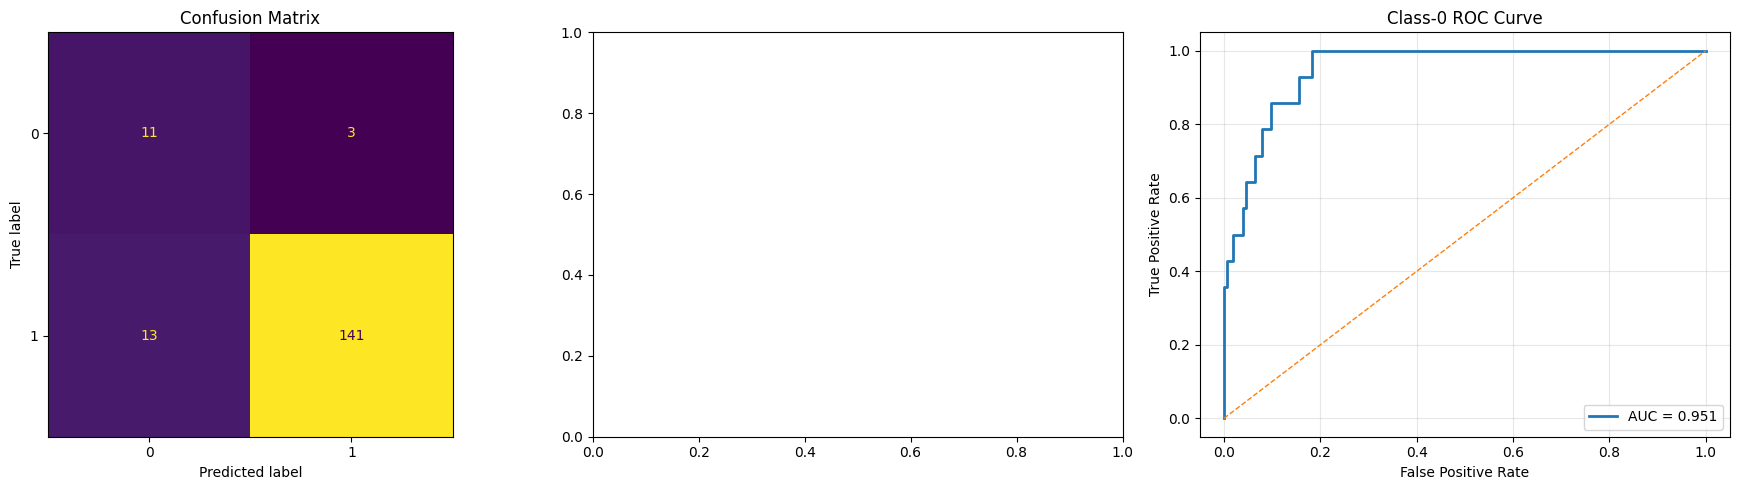

Class-0 ROC AUC: 0.9508


In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

# Get logits once and reuse for all diagnostics.
test_outputs = trainer.predict(test_dataset)
logits = test_outputs.predictions
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()

y_true = np.array(test_labels)
y_pred = np.argmax(probs, axis=1)

# 1) Confusion matrix (argmax predictions)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
print("Confusion Matrix (rows=true, cols=pred):")
print(cm)

# 2) Class-0 one-vs-rest curves using probability of class 0.
y_true_0 = (y_true == 0).astype(int)
y_score_0 = probs[:, 0]


fpr_0, tpr_0, _ = roc_curve(y_true_0, y_score_0)
roc_auc_0 = roc_auc_score(y_true_0, y_score_0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Confusion Matrix")


axes[2].plot(fpr_0, tpr_0, linewidth=2, label=f"AUC = {roc_auc_0:.3f}")
axes[2].plot([0, 1], [0, 1], linestyle="--", linewidth=1)
axes[2].set_title("Class-0 ROC Curve")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend(loc="lower right")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


print(f"Class-0 ROC AUC: {roc_auc_0:.4f}")

## 5. Evaluation with Custom Examples

Tokenizer → converts to input_ids + attention_mask
   ↓
Model (DistilBERT)
   ↓
Logits (raw scores)
   ↓
Softmax → probabilities
   ↓
Argmax → final class (0 or 1)

In [27]:
POSITIVE_CLASS_THRESHOLD = 0.60  # Tune on validation set for desired precision/recall trade-off.

def predict_sentiment(text):
    model.eval()
    cleaned_text = clean_review_text(text)
    
    inputs = tokenizer(
        cleaned_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=32
    )

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)

    negative_prob = probs[0][0].item()
    positive_prob = probs[0][1].item()
    pred_id = 1 if positive_prob >= POSITIVE_CLASS_THRESHOLD else 0

    id2label = {0: "negative", 1: "positive"}
    pred_label = id2label.get(pred_id, id2label.get(str(pred_id), str(pred_id)))

    return {
        "text": text,
        "cleaned_text": cleaned_text,
        "prediction_id": pred_id,
        "prediction_label": pred_label,
        "confidence": positive_prob if pred_id == 1 else negative_prob,
        "negative_probability": negative_prob,
        "positive_probability": positive_prob,
        "positive_threshold": POSITIVE_CLASS_THRESHOLD
    }

In [30]:
print(predict_sentiment("This product is amazing, I loved it!"))
print(predict_sentiment("Worst experience ever, totally disappointed"))

{'text': 'This product is amazing, I loved it!', 'cleaned_text': 'this product is amazing, i loved it!', 'prediction_id': 1, 'prediction_label': 'positive', 'confidence': 0.7086566090583801, 'negative_probability': 0.2913433909416199, 'positive_probability': 0.7086566090583801, 'positive_threshold': 0.6}
{'text': 'Worst experience ever, totally disappointed', 'cleaned_text': 'worst experience ever, totally disappointed', 'prediction_id': 0, 'prediction_label': 'negative', 'confidence': 0.48167043924331665, 'negative_probability': 0.48167043924331665, 'positive_probability': 0.5183296203613281, 'positive_threshold': 0.6}


## 7. Save Model Artifacts

In [37]:
import json

id2label = {0: "negative", 1: "positive"}
label2id = {"negative": 0, "positive": 1}

# Persist label metadata in model config for safe downstream loading.
model.config.id2label = id2label
model.config.label2id = label2id

model.save_pretrained("sentiment_model")
tokenizer.save_pretrained("sentiment_model")

with open("sentiment_model/label_mapping.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "id2label": {str(k): v for k, v in id2label.items()},
            "label2id": label2id,
        },
        f,
        indent=2,
    )

eval_metrics = trainer.evaluate()
with open("sentiment_model/eval_metrics.json", "w", encoding="utf-8") as f:
    json.dump(eval_metrics, f, indent=2)

preprocess_config = {
    "uses_clean_review_text": True,
    "contraction_expansion": True,
    "url_html_email_removal": True,
    "kept_punctuation": [".", ",", "!", "?", ";", ":"],
    "max_length": 32,
}
with open("sentiment_model/preprocess_config.json", "w", encoding="utf-8") as f:
    json.dump(preprocess_config, f, indent=2)

print("Saved model, tokenizer, label mapping, eval metrics, and preprocessing config.")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.49it/s]
d:\vscode\E-Commerce-Review-Intelligence-System\torch\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 